In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

In [17]:
ds = xr.open_dataset("/Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/untracked/forcing/global_ERA5_SCOTIA_forcing.nc")
time = ds.time.values
latitude = ds.latitude.values
longitude = ds.longitude.values

In [47]:
def wind_burst(time, latitude, longitude):
    time = np.array(time)
    latitude = np.array(latitude)
    longitude = np.array(longitude)

    lat0, lat1 = 20, 40
    lon0, lon1 = -45, -30

    lat_mask = (latitude >= lat0) & (latitude <= lat1)
    lon_mask = (longitude >= lon0) & (longitude <= lon1)

    lat_profile = np.zeros_like(latitude, dtype=float)
    lon_profile = np.zeros_like(longitude, dtype=float)

    lat_profile[lat_mask] = np.sin(
        np.pi * (latitude[lat_mask] - lat0) / (lat1 - lat0)
    )
    lon_profile[lon_mask] = np.sin(
        np.pi * (longitude[lon_mask] - lon0) / (lon1 - lon0)
    )

    spatial_pattern = lat_profile[:, None] * lon_profile[None, :]

    return np.broadcast_to(
        spatial_pattern[None, :, :],
        (time.shape[0], latitude.shape[0], longitude.shape[0]),
    ).copy()

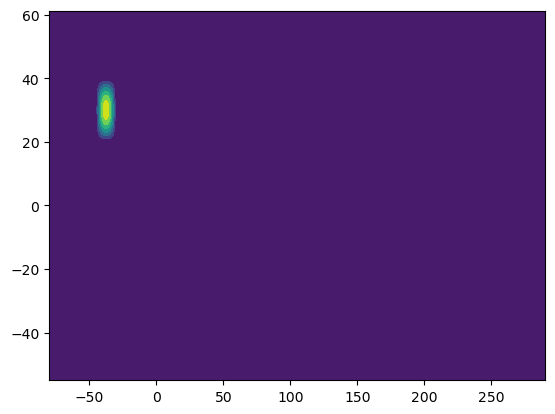

In [52]:
plt.contourf(longitude, latitude, wind_burst(time[:1], latitude, longitude)[0])

In [13]:
wind_burst_stat = wind_burst[0,:,:].copy()

In [10]:
wind_burst_stat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(466, 1481), dtype=float32)